In [1]:
import os
import tarfile
import urllib.request

from country_name import country_name_rus

CL =[ "Afganistan","China","CAR", "Ethiopia",
      "India", "Iran","KNDR", "Libya", "Morocco", "Sudan",
      "Syria", "Turkey", "Argentina", "DRK_Congo", "Burkina_Faso",
      "Niger", "Mali", "Senegal", "Egipet", "Gvineya", "Venesuela",
      "Algeria", "Zimbabve", "Tunis", "Boliviya", "Braziliya",
      "Yuar", "Burundi", "Ruanda", "Mongoliya", 'Pakistan', 
     "Chili", 'Bangladesh', 'Benin', 'Gabon', 'Laos', 'Chad' , 
     'Keniya', 'Indoneziya','Iordaniya', 'Irak', 'Kambodzha', 'Kuba',
     'Tailand','Urugvay', 'Kamerun', 'Madagaskar', 'Mozambik', 'Yaponiya',
     'Mexico', 'Oae','Saudovskaya_araviya', 'Yemen', 'Pakistan', 'Laos', 'RK_Congo',
     'angola', 'belorussiya', 'litva', 'franciya', 'botsvana', 'vengriya',
     'italiya', 'germaniya' , 'palestina', 'izrail', 'tayvan', 'tanzaniya',
     'ispaniya',  'livan', 'oman','paragvay', 'peru', 'portugaliya', 'ssha','kolumbiya', 'uganda', 'nigeriya',
     'gana', 'Respublika-koreya', 'ekvatorialnaya-gvineya', 'kot-d-ivuar',  'namibiya', 'zambiya','vetnam',  'myanma'
    ]

DIR_PATH= {}
DOWNLOAD_ROOT = "D:/ML/"
print(DOWNLOAD_ROOT)
#DATASET_PATH = os.path.join("datasets", "Countries")
DATASET_PATH = os.path.join("datasets", "Countries_V3")

for item in CL:
    DIR_PATH[country_name_rus[item]] = os.path.join(DATASET_PATH, item)
    
filenames = {}
for items in DIR_PATH.keys():   
    filenames[items] = [name for name in sorted(os.listdir(DIR_PATH[items])) ] 
    print(items)

D:/ML/
Афганистан
КНР
Центрально-Африканская Республика
Эфиопия 
Индия
Иран
КНДР
Ливия
Морокко
Судан
Сирия
Турция
Аргентина
ДРК (Конго)
Буркина-Фасо
Нигер
Мали
Сенегал
Египет
Гвинея
Венесуэла
Алжир
Зимбабве
Тунис
Боливия
Бразилия
ЮАР
Бурунди
Руанда
Монголия
Пакистан
Чили
Бангладеш
Бенин
Габон
Лаос
Чад
Кения
Индонезия
Иордания
Ирак
Камбоджа
Куба
Таиланд
Уругвай
Камерун
Мадагаскар
Мозамбик
Япония
Мексика
ОАЭ
Саудовская Аравия
Йемен
Республика Конго
Ангола
Беларусь
Литва
Франция
Ботсвана
Венгрия
Италия
Германия
Палестина
Израиль
КНР (Тайвань)
Танзания
Испания
Ливан
Оман
Парагвай
Перу
Португалия
США
Колумбия
Уганда
Нигерия
Гана
Южная Корея
Экваториальная Гвинея
Кот-д'Ивуар
Намибия
Замбия
Вьетнам
Мьянма


In [2]:
len(country_name_rus.keys())

84

In [3]:
stemming=True # Stemming control
if stemming:
    from nltk.stem.snowball import SnowballStemmer
    stemmer = SnowballStemmer("russian")

In [4]:
from stop_words_ru import ru_stopwords

In [5]:
load_from_DB = True # True - Загрузка БД из json файла
                        # False - Пересборка  json файла из отдельных текстовых файлов

In [6]:
from charset_normalizer import from_path
import string

def remove_chars_from_text(text, chars):
    # return "".join([ch for ch in text if ch not in chars])
    content = ''
    for ch in text:
        if ch not in chars:
            content = content + ''.join(ch)
        else:
            content = content + ''.join(' ')
    return content

import re

def remove_emojis(data):
    emoj = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002500-\U00002BEF"  # chinese char
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U0001f926-\U0001f937"
        u"\U00010000-\U0010ffff"
        u"\u2640-\u2642" 
        u"\u2600-\u2B55"
        u"\u200d"
        u"\u23cf"
        u"\u23e9"
        u"\u231a"
        u"\ufe0f"  # dingbats
        u"\u3030"
                      "]+", re.UNICODE)
    return re.sub(emoj, ' ', data)
spec_chars = string.punctuation + '\r' + '\n\xa0«»\t—…' 

def clean_text (post_text):    
    text_post = re.sub(r'https?:\/\/.*[\r\n]*', ' ', post_text, flags=re.MULTILINE)
    text_post = re.sub(r'#[^\s|\n]+', ' ', text_post)
    text_post = remove_emojis(text_post)
    text_post = text_post.replace('Тут была французская Западная Африка | Подписаться', ' ')
    text_post = text_post.replace('Африканская инициатива | Подписаться', ' ')
    text_post = text_post.replace('@sex_drugs_kahlo — латиноамериканское счастье [нет]', ' ')
    text_post = text_post.replace('Подписаться | Обратная связь', ' ')
    text_post = text_post.replace('  ', ' ')
    text_post = text_post.replace('  ', ' ')
    text_post = text_post.replace('  ', ' ')
    text_post = text_post.replace('/Синьхуа/', ' ')
    text_post = text_post.replace('[Full Text]', ' ')
    return text_post

import time
import random
import codecs, json
from datetime import datetime

def json_cleaning_stemm (json_file_name):
    with open(json_file_name, encoding='utf-8') as json_file:
        article_data = json.load(json_file)
    result_data = {}   
    for item in article_data.keys():
        x_temp = []
        content = str(article_data[item]['text']).lower()
        content = remove_emojis(content)
        content = remove_chars_from_text(content, spec_chars)
        content = remove_chars_from_text(content, string.digits)
        for i in range(1, 10):
            content = content.replace('  ', ' ')
        filtered_words = []
        for token in content.split():
            if token not in ru_stopwords and len(token) > 2:
                if stemming and token is not None:
                    filtered_words.append(stemmer.stem(token))
                    # print('{} -{}'.format(token,stemmer.stem(token)))
                else:
                    filtered_words.append(token)
    
        content = ' '.join(filtered_words)   
        result_data [item] = {'text': content, 'country': article_data[item]['country']}
    try: 
        with codecs.open('{}_cleaning_stemm.json'.format(json_file_name[:-5]), 'w', encoding='utf-8') as f:
             f.write(json.dumps(result_data, sort_keys = True, ensure_ascii=False))    
    except Exception as ex:
        print(ex)
    return


In [7]:
import pandas as pd 
    #Reading the JSON File 
x_temp = []
y_temp = []

if load_from_DB:
    json_cleaning_stemm ('Country_DB_V4_25-01-2025.json')     
    df = pd.read_json('Country_DB_V4_25-01-2025_cleaning_stemm.json').T
else:
    for item in filenames.keys():
        post_temp=[]
        for names in filenames[item]:
            content = str(from_path(DIR_PATH[item]+"\\"+names).best())            
            content = clean_text(content)                
            x_temp.append(content)
            y_temp.append(item)
    try:
        article_data ={}
        for article_id in range(0, len(x_temp)):
            #print (article_id)
            article_data [article_id] = {'text': x_temp [article_id], 'country': y_temp [article_id]}
        time = datetime.now().strftime("%d-%m-%Y")
        with codecs.open('Country_DB_V4_{}.json'.format(time), 'w', encoding='utf-8') as f:
             f.write(json.dumps(article_data, sort_keys = True, ensure_ascii=False))
        json_cleaning_stemm ('Country_DB_V4_{}.json'.format(time))     
        df = pd.read_json('Country_DB_V4_{}_cleaning_stemm.json'.format(time)).T
    except Exception as ex:
        print(ex)

json_cleaning_stemm ('Country_DB_V4_checked_25-01-2025.json')
df_checked = pd.read_json('Country_DB_V4_checked_25-01-2025_cleaning_stemm.json').T
MergeJson = pd.concat([df, df_checked], axis=0)
        



In [8]:
df_checked

,country,text
0,Судан,судан сезон наводнен пострада тысяч человек су...
1,Судан,срыв америка суданск переговор каир переходн с...
10,Турция,глав суверен совет суда встрет президент турц ...
100,Ирак,президент ира масуд пезешкиа правительствен де...
1000,КНР,кита успешн запуст нов групп спутник дистанцио...
...,...,...
995,Иран,ира призва переосмысл поведен отношен западн а...
996,Иран,возобновлен работ иранск посольств сир сто пов...
997,Южная Корея,отстранен власт президент гроз нов вызов допро...
998,КНР,цзиньпин призва провинц хайнан вписа собствен ...


In [9]:
df

,country,text
0,Афганистан,источник мест пишут вертолет таджикиста отстре...
1,Афганистан,присутств запад афганистан минимальн поддержк ...
10,Афганистан,руководств афганск талиба запрещен террористич...
100,Афганистан,росс направ афганиста спецборт гуманитарн помо...
1000,КНР,офис казахск китайск компан cnpc актобемунайга...
...,...,...
9995,Руанда,сми руанд обвин конг причастн похищен двух руа...
9996,Руанда,африканск союз выраз беспокойств кризис отноше...
9997,Руанда,церков англ раскритикова план правительств отп...
9998,Руанда,трасс подтверд британ начнет отправля нелегаль...


In [10]:
len(set(MergeJson["country"].tolist()))

84

In [11]:
for country in set(MergeJson["country"].tolist()): 
    sum = MergeJson[MergeJson["country"]==country]['text'].count()
    print(f'{country} - {sum} ')

Экваториальная Гвинея - 190 
Алжир - 189 
Уругвай - 44 
Лаос - 206 
Аргентина - 149 
Куба - 229 
Морокко - 684 
Испания - 201 
Замбия - 200 
Йемен - 209 
Колумбия - 196 
КНР (Тайвань) - 211 
Монголия - 88 
Бангладеш - 121 
Афганистан - 463 
Камерун - 224 
Бенин - 193 
Германия - 211 
Республика Конго - 206 
Ливан - 203 
Чад - 246 
Индия - 1406 
Зимбабве - 196 
Мадагаскар - 102 
Перу - 210 
Танзания - 217 
Сенегал - 152 
Сирия - 141 
Парагвай - 211 
Руанда - 208 
Нигерия - 250 
Таиланд - 74 
Мали - 301 
Турция - 1133 
Франция - 210 
Мозамбик - 236 
Иран - 642 
Мьянма - 199 
Кения - 207 
США - 247 
Ангола - 232 
Чили - 83 
Египет - 263 
ЮАР - 70 
Оман - 214 
Бурунди - 73 
Мексика - 1080 
Центрально-Африканская Республика - 545 
Ирак - 69 
Тунис - 125 
КНДР - 395 
КНР - 2422 
Эфиопия  - 346 
Камбоджа - 70 
Боливия - 118 
Гвинея - 106 
Венгрия - 207 
Гана - 231 
Венесуэла - 144 
ДРК (Конго) - 469 
Италия - 207 
Кот-д'Ивуар - 223 
Иордания - 211 
Бразилия - 243 
Уганда - 218 
ОАЭ - 385 
Изр

In [12]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
if load_from_DB:
    X = np.array(MergeJson['text'], dtype=object)
    y = np.array(MergeJson['country'])
else:
    X = np.array(x_temp, dtype=object)
    y = np.array(y_temp)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [13]:
len(X)

23703

In [14]:
len(y)

23703

In [15]:
MergeJson

,country,text
0,Афганистан,источник мест пишут вертолет таджикиста отстре...
1,Афганистан,присутств запад афганистан минимальн поддержк ...
10,Афганистан,руководств афганск талиба запрещен террористич...
100,Афганистан,росс направ афганиста спецборт гуманитарн помо...
1000,КНР,офис казахск китайск компан cnpc актобемунайга...
...,...,...
995,Иран,ира призва переосмысл поведен отношен западн а...
996,Иран,возобновлен работ иранск посольств сир сто пов...
997,Южная Корея,отстранен власт президент гроз нов вызов допро...
998,КНР,цзиньпин призва провинц хайнан вписа собствен ...


In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,5), min_df=6)
print (tfidf)
#tfidf= CountVectorizer(max_features=20000)
X_train_transformed = tfidf.fit_transform(X_train)
#rf = DecisionTreeClassifier(max_depth=depth , min_samples_leaf=50)
rf = DecisionTreeClassifier()
rf.fit(X_train_transformed, y_train)

y_pred = rf.predict_proba(X_train_transformed)[:, 1]
score = cross_val_score(rf, X_train_transformed, y_train, cv=3, verbose=3)
print(score.mean())
print(cross_val_score(rf, X_train_transformed, y_train, scoring='accuracy'))
print(cross_val_score(rf, X_train_transformed, y_train, scoring='f1_macro'))    

TfidfVectorizer(max_features=20000, min_df=6, ngram_range=(1, 5))
[CV] END ................................ score: (test=0.787) total time=  15.5s
[CV] END ................................ score: (test=0.786) total time=  15.9s
[CV] END ................................ score: (test=0.788) total time=  16.1s
0.787005838863836
[0.78999699 0.79300994 0.78963231 0.78300181 0.78360458]
[0.74685762 0.74928999 0.74740116 0.74179421 0.74606996]


In [17]:
from sklearn.metrics import precision_score, recall_score

X_test_transformed = tfidf.transform(X_test)

rf.fit(X_test_transformed, y_test)

y_pred = rf.predict(X_test_transformed)

print("Precision: {:.2f}%".format(100 * precision_score(y_test, y_pred, average='weighted')))
print("Recall: {:.2f}%".format(100 * recall_score(y_test, y_pred, average='weighted')))

Precision: 98.58%
Recall: 98.44%


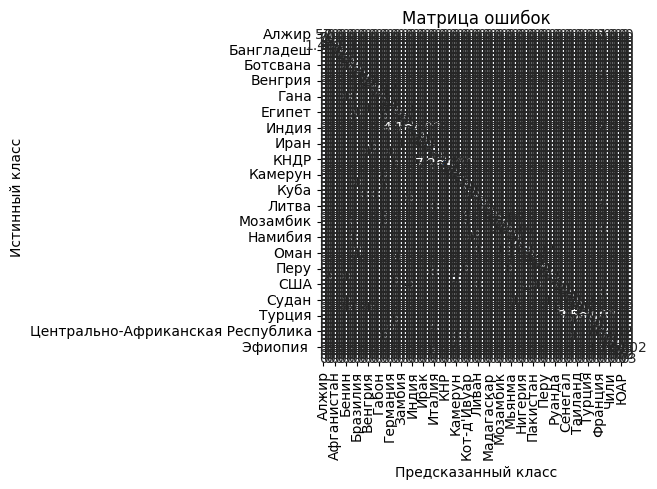

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns #pip install seaborn
from sklearn.metrics import confusion_matrix
import pandas as pd
# Создать матрицу ошибок
matrix = confusion_matrix(y_test, y_pred)
# Создать структуру DataFrame библиотеки pandas
dataframe = pd.DataFrame(matrix, index=rf.classes_, columns=rf.classes_)
# Создать тепловую карту
sns.heatmap(dataframe, annot=True, cbar=None, cmap="Blues")
plt.title("Maтpицa ошибок")
plt.tight_layout()
plt.ylabel("Истинный класс")
plt.xlabel("Предсказанный класс")
plt.show()

In [38]:
from sklearn.ensemble import RandomForestClassifier
#from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=6000, ngram_range=(1,5), min_df=6)
X_train_transformed = tfidf.fit_transform(X_train)

#rf = DecisionTreeClassifier(max_depth=depth , min_samples_leaf=50)  n_estimators= 277
rf_RandomForest = RandomForestClassifier(random_state=3, n_jobs=-1, class_weight="balanced", oob_score=True, max_depth=120)
rf_RandomForest.fit(X_train_transformed, y_train)

y_pred = rf_RandomForest.predict_proba(X_train_transformed)[:, 1]
score = cross_val_score(rf_RandomForest, X_train_transformed, y_train, cv=3, verbose=3)
print(score.mean())
print(cross_val_score(rf_RandomForest, X_train_transformed, y_train, scoring='accuracy'))
print(cross_val_score(rf_RandomForest, X_train_transformed, y_train, scoring='f1_macro')) 
print(rf_RandomForest.oob_score_)

[CV] END ................................ score: (test=0.855) total time=   3.6s
[CV] END ................................ score: (test=0.855) total time=   3.7s
[CV] END ................................ score: (test=0.853) total time=   3.7s
0.8543272948166883
[0.85778849 0.86501958 0.84900542 0.85201929 0.85473177]
[0.83705283 0.83472091 0.82132367 0.82866584 0.83111498]
0.8486620057859209


In [39]:
from sklearn.metrics import precision_score, recall_score

X_test_transformed = tfidf.transform(X_test)

rf_RandomForest.fit(X_test_transformed, y_test)

y_pred_RandomForest = rf_RandomForest.predict(X_test_transformed)

print("Precision: {:.2f}%".format(100 * precision_score(y_test, y_pred_RandomForest, average='weighted')))
print("Recall: {:.2f}%".format(100 * recall_score(y_test, y_pred_RandomForest, average='weighted')))

Precision: 97.90%
Recall: 97.68%


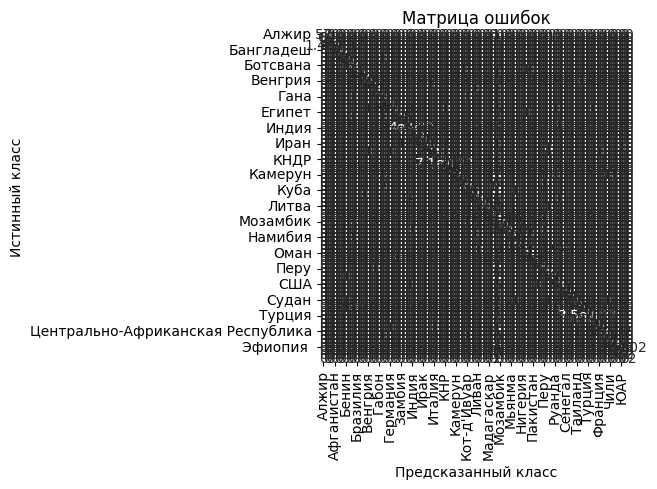

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns #pip install seaborn
from sklearn.metrics import confusion_matrix
import pandas as pd
# Создать матрицу ошибок
matrix = confusion_matrix(y_test, y_pred_RandomForest)
# Создать структуру DataFrame библиотеки pandas
dataframe = pd.DataFrame(matrix, index=rf_RandomForest.classes_, columns=rf_RandomForest.classes_)
# Создать тепловую карту
sns.heatmap(dataframe, annot=True, cbar=None, cmap="Blues")
plt.title("Maтpицa ошибок")
plt.tight_layout()
plt.ylabel("Истинный класс")
plt.xlabel("Предсказанный класс")
plt.show()

In [41]:
impoгtances = rf_RandomForest.feature_importances_
feature_imp_df = pd.DataFrame({'Word': tfidf.get_feature_names_out(), 'Importance': impoгtances}).sort_values('Importance', ascending=False) 
print(feature_imp_df[:50])

            Word  Importance
2284  мадагаскар    0.009573
467       бурунд    0.009390
5373       тунис    0.009351
5427       уганд    0.008538
2243        литв    0.007698
2655       намиб    0.007573
2605       мьянм    0.007496
5209     таиланд    0.007202
3334         пер    0.007147
1493        замб    0.007009
1615     зимбабв    0.006712
2548    мозамбик    0.006682
2825       нигер    0.006666
1890     камбодж    0.006583
5796         чил    0.006543
1997      колумб    0.006486
3657    португал    0.006476
1893     камерун    0.006393
164        алжир    0.006298
915          ган    0.006269
4521       руанд    0.006017
223     аргентин    0.005873
1981        кндр    0.005845
922         гвин    0.005838
897        габон    0.005815
193        ангол    0.005782
2318      марокк    0.005771
5993        япон    0.005770
3053         ома    0.005718
5233      танзан    0.005718
2187        лаос    0.005639
1797      иордан    0.005590
311    бангладеш    0.005479
5942       эфи

In [42]:
with open('./datasets/feature_importances_.txt', "w", encoding="utf-8") as some_file:
    some_file.write(feature_imp_df.to_string())

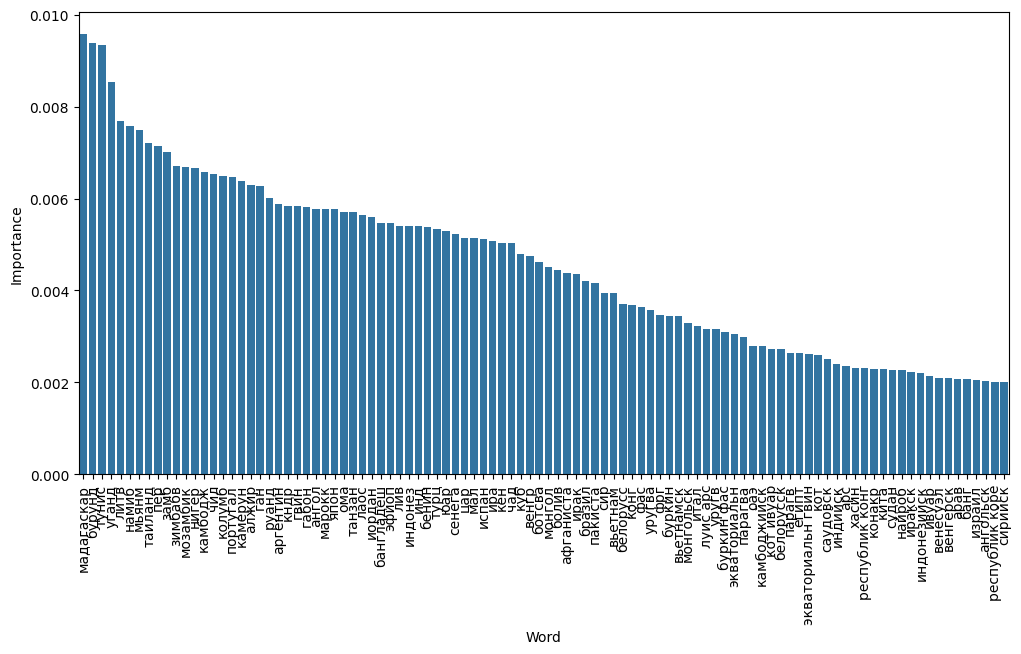

In [43]:
import pandas as pd
import seaborn as sns
plt.figure(figsize=(12, 6))
ax = sns.barplot(x="Word", y="Importance", data=feature_imp_df[:100])

ax.tick_params(axis='x', labelrotation=90)
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
# ax.set_xticks(ticks=ax.get_xticks(), labels=ax.get_xticklabels(), rotation=45, ha='right')
plt.show()


In [51]:
new_text = ['Нигер последовал примеру Мали, разорвав связи с Украиной после того, как пресс-секретарь разведывательного агентства Министерства обороны Украины признал, что Украина оказывала поддержку повстанцам, которые убили малийских вооруженных сил и российских агентов 25-27 июля в Тинзауатене, на севере Мали, недалеко от границы с Алжиром.Посол Украины в Сенегале также выразил безоговорочную поддержку малийским повстанцам, что привело к вызову посла в МИД Сенегала.',
            'Еще новости афганской промышленности. В Кандагаре спустя 18 лет возобновила работу текстильная фабрика. Официальные лица говорят, что они отремонтировали оборудование на фабрике за шесть месяцев, сообщают афганское СМИ. По словам работников фабрики, с возобновлением работы фабрики созданы рабочие места. 69-летний Мохаммад, проработавший на текстильной фабрике в Кандагаре значительное время, рад вернуться на работу.',
           'Накопленное непонимание между Китаем и США не может быть решено лишь одним подобным изящным жестом. Страны расходятся по широкому кругу вопросов, санкционный механизм против Китая не ослаблен. Поэтому отправка панд – это скорее демонстрация миролюбивой позиции Китая в противовес США.',
            'В Алжире, как правило, на похоронах мужчины сидят около дома, хорошо, если есть сад или терраса, а женщины в доме, надеть платок женщина должна обязательно, даже если в обычной жизни она не покрывает голову. Если покойный жил в квартире, то прямо во дворе ставят стулья и шатры со столами для мужчин.Готовят либо нанятые кухарки, либо родственницы покойного. Пока составляла пост от подруги услышала,что в их семье часто еду приносят те, кто приходит в дом, а готовить должны невестки, а не дочери умершего. Мой муж сказал, что это совершенно необязательно, на похоронах его бабушки готовили только её дочери, это было их желание и никаких особых правил на счёт этого нет. Обязательного блюда на поминки в Алжире нет. Народ приходит помянутьот трех дней до недели, если у человека была большая семья и много знакомых!Кормят традиционными блюдами: суп-шорба, кус-кус/беркукес/тлитли с мясом и т.д.Могилу посещают каждое утро, в течении трех дней. Через 40 дней устанавливают небольшое надгробие, никаких памятников,вычурных элементов. На надгробии имя, фамилия, даты рождения и смерти, фотографий нет. Вроде бы написала всё, что знала. Задавайте вопросы в комментариях, если таковые имеются.',
            'Сегодня в Венесуэле проходят президентские выборы. Мой коллега Дмитрий Морозов рассуждает, как их итоги могут повлиять на дальнейший путь страны. Вот самое важное из его статьи.📍В выборах один тур, участвуют десять кандидатов, однако только двое имеют реальные шансы на победу: действующий президент Николас Мадуро и Эдмундо Гонсалес Уррутия, кандидат от Единой демократической платформы, объединяющей наиболее значимые оппозиционные партии.',
            'С возвращением Трампа в Белый дом «тропический Трамп» Жаир Болсонару осмелел и заявил, что, будь он сейчас президентом Бразилии, вышел бы из БРИКС. И попросился бы в Североамериканское соглашение о свободной торговле (NAFTA), к США, Канаде и Мексике. Он даже предложил переименовать его в Американское соглашение о свободной торговле (AFTA). Очень уж Болсонару раздражает, что теперь в БРИКС входят Куба и Боливия (правда, они не входят, а являются странами-партнерами. Но спасибо, хоть Испанию как страну БРИКС не перечислил). Только вот когда Болсонару действительно был президентом Бразилии, он из БРИКС не выходил. Хотя многие тогда и пророчили.',
            'Вид на императорский дворец в Гондэре. Гравюра на дереве (ксилография), 1868 год. Работа Иоганна Мартина Бернатца (Johann Martin Bernatz). Из книги Теодора фон Хойглина (Martin Theodor von Heuglin) «Путешествие в Абиссинию, страну галласов, Восточный Судан и Хартум в 1861 и 1862 годах» (Reise nach Abessinien, den Gala-Ländern, Ost- Sudán und Chartúm in den Jahren 1861 und 1862).'
           
           ]
x_temp = []
for post_temp in new_text:
        content = str(post_temp).lower()  
        content = remove_emojis(content)
        content = remove_chars_from_text(content, spec_chars)
        content = remove_chars_from_text(content, string.digits)
        for i in range(1, 10):
            content = content.replace('  ', ' ')
        filtered_words = []
        for token in content.split():
            if token not in ru_stopwords and len(token)>2:
                if stemming and token is not None:
                    filtered_words.append(stemmer.stem(token))
                    #print('{} -{}'.format(token,stemmer.stem(token)))
                else:
                    filtered_words.append(token)
                      
        content = ' '.join(filtered_words)  
        #if ngram_replace:
        #    for item in vocabl:
        #        if item.replace('_', ' ') in vocabl:
         #           content.replace(item.replace('_', ' '), item)
                    #print(item)                
        x_temp.append(content)
count = CountVectorizer(ngram_range=(1,5), vocabulary = set(tfidf.get_feature_names_out()))
#count = CountVectorizer(vocabulary = set(X_train_words))
X_t = count.transform(x_temp)
#print(count.vocabulary_)
accuracy = rf_RandomForest.predict(X_t)
print (accuracy)

['Сенегал' 'Чили' 'КНР' 'Алжир' 'Венесуэла' 'Боливия' 'Судан']


In [52]:
probabilities = rf_RandomForest.predict_proba(X_t)
for i, prob in enumerate(rf_RandomForest.predict(X_t)):
    print(f"Sample {i}")
    for ix , probx in enumerate(rf_RandomForest.classes_):
        if probabilities[i][ix]>0.02:
            print(f" Class {probx}, Probability = {probabilities[i][ix]:.2f}")

Sample 0
 Class Алжир, Probability = 0.18
 Class Мали, Probability = 0.25
 Class Нигер, Probability = 0.08
 Class Нигерия, Probability = 0.14
 Class Сенегал, Probability = 0.27
Sample 1
 Class Афганистан, Probability = 0.03
 Class Габон, Probability = 0.02
 Class Италия, Probability = 0.03
 Class КНР, Probability = 0.02
 Class Ливия, Probability = 0.03
 Class Мексика, Probability = 0.05
 Class Морокко, Probability = 0.02
 Class Турция, Probability = 0.02
 Class Центрально-Африканская Республика, Probability = 0.02
 Class Чили, Probability = 0.06
Sample 2
 Class Италия, Probability = 0.03
 Class КНР, Probability = 0.73
Sample 3
 Class Алжир, Probability = 0.61
 Class Беларусь, Probability = 0.02
 Class Камерун, Probability = 0.04
 Class Морокко, Probability = 0.07
Sample 4
 Class Бразилия, Probability = 0.02
 Class Венесуэла, Probability = 0.71
 Class Италия, Probability = 0.04
 Class Парагвай, Probability = 0.06
 Class Экваториальная Гвинея, Probability = 0.02
Sample 5
 Class Боливия, 

In [46]:
rf_RandomForest.classes_

array(['Алжир', 'Ангола', 'Аргентина', 'Афганистан', 'Бангладеш',
       'Беларусь', 'Бенин', 'Боливия', 'Ботсвана', 'Бразилия',
       'Буркина-Фасо', 'Бурунди', 'Венгрия', 'Венесуэла', 'Вьетнам',
       'Габон', 'Гана', 'Гвинея', 'Германия', 'ДРК (Конго)', 'Египет',
       'Замбия', 'Зимбабве', 'Израиль', 'Индия', 'Индонезия', 'Иордания',
       'Ирак', 'Иран', 'Испания', 'Италия', 'Йемен', 'КНДР', 'КНР',
       'КНР (Тайвань)', 'Камбоджа', 'Камерун', 'Кения', 'Колумбия',
       "Кот-д'Ивуар", 'Куба', 'Лаос', 'Ливан', 'Ливия', 'Литва',
       'Мадагаскар', 'Мали', 'Мексика', 'Мозамбик', 'Монголия', 'Морокко',
       'Мьянма', 'Намибия', 'Нигер', 'Нигерия', 'ОАЭ', 'Оман', 'Пакистан',
       'Палестина', 'Парагвай', 'Перу', 'Португалия', 'Республика Конго',
       'Руанда', 'США', 'Саудовская Аравия', 'Сенегал', 'Сирия', 'Судан',
       'Таиланд', 'Танзания', 'Тунис', 'Турция', 'Уганда', 'Уругвай',
       'Франция', 'Центрально-Африканская Республика', 'Чад', 'Чили',
       'Экваториал

In [47]:
import pickle
from datetime import datetime

time = datetime.now().strftime("%d-%m-%Y")

with open('country_post-model_ngram_rf_tfidf_V4_022_{}_lowRAM.bin'.format(time), 'wb') as f_out:
    pickle.dump([rf_RandomForest, tfidf.get_feature_names_out()], f_out)